In [1]:
# General imports
from netsim.netSimPy import *
from netsim.netSimPy.common.evaluators import NetworkEvaluator

# Jorge:
from netsim.netSimPy.common.allocators import alphaBalancing

/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import itertools

available_bands = ["C", "S", "L", "E"]
simulators = {}

# for bands in list(itertools.permutations(available_bands)):
for bands in [["L", "S", "C", "E"], ["L", "E", "S", "C"]]:
    # if bands[0] != "LESC":
    #     continue
    allocator = alphaBalancing(3, [1], [bands])

    M_LAMBDA = 200000
    network = Network(
        networkFileName="../../../../networks/nsfnet/network.json",
        pathsFileName="../../../../networks/nsfnet/routes.json",
        bitrateFilename="../../../../networks/nsfnet/bitrates_4_bands.json",
    )
    generator = EventsGenerator(mLambda=M_LAMBDA)

    sim_args1 = dict(
        eventsGenerator=generator,
        network=network,
        allocator=allocator,
    )
    sim = NetworkSimulator(**sim_args1)
    name = "".join(bands)
    simulators[name] = sim


N_EVALUATIONS = 2000000
# for traffic in [50000, 100000, 150000, 200000, 250000, 300000, 350000, 400000]:
for name, simulator in simulators.items():
    if name == "LSCE":
        traffics = [400000]
    if name == "LESC":
        traffics = [350000]
    for traffic in traffics:
        callback = NetworkEvaluator(f"{name}_{traffic}")
        simulator.reset()
        simulator.setLambda(traffic)
        print(f"Running simulation for {name} with lambda: {traffic}")
        simulator.run(N_EVALUATIONS, callback)
        print("\n")

Running simulation for LSCE with lambda: 400000
Blocking probability: 0.0642


Running simulation for LESC with lambda: 350000
Blocking probability: 0.052241




In [3]:
from typing import Any
import pandas as pd
import ast
from pathlib import Path
import glob


def read_csv(path: Path):
    # Read the CSV, skip the first comment line
    df = pd.read_csv(path.resolve(), comment="#")
    # Take the first row and convert it to a dict (columns become keys)
    row_dict = df.iloc[0].to_dict()
    # Try to parse each value that looks like a dictionary
    for key, value in row_dict.items():
        if isinstance(value, str) and value.strip().startswith(("{", "[")):
            try:
                row_dict[key] = ast.literal_eval(value)
            except Exception:
                pass  # Leave as-is if not safely parsable
    return row_dict

In [ ]:
files = glob.glob("./salva/*.csv")

# results -> dict[str, list[dict[str,Any]]]
# ej: results["50000"][0]["steps"]
# res = 2.000.000
results: dict[str, list[dict[str, Any]]] = {}


for file in glob.glob("./salva/*.csv"):
    path = Path(file)
    name = path.name
    # print(name)
    # if (
    #     name == "LSCE_400000net.evaluations.csv"
    #     # or
    #     # name == "LESC_350000net.evaluations.csv"
    # ):
    #     continue
    base_n = name.split(".")[0].split("_")
    order = base_n[0]
    load = base_n[-1][:-3]
    if not load in results:
        results[load] = []
    csv = read_csv(path)
    csv["order"] = order
    results[load].append(csv)

# results["50000"][0]["order"]

In [7]:
# block_prob ->
# ej: block_prob["50000"] = [("LSCE", 0.01)]
# data-> list[dict[str, Any]]
block_prob: dict[str, list[tuple[str, float]]] = {}


def l_func(data_dict: dict[str, Any]):
    return data_dict["blockedEvents"]


for key, data in results.items():
    min_val = min(map(l_func, data))
    all_min_probs = [d for d in data if l_func(d) == min_val]

    block_prob[key] = list(map(lambda x: (x["order"], x["blockedEvents"]), all_min_probs))

    print(key, block_prob[key])

400000 [('CSEL', 125490)]
350000 [('CSEL', 96106)]
100000 [('LESC', 0), ('SLCE', 0), ('LCSE', 0), ('SECL', 0), ('LSEC', 0), ('LCES', 0), ('ESLC', 0), ('ECLS', 0), ('ECSL', 0), ('ELSC', 0), ('LECS', 0), ('SLEC', 0), ('SCEL', 0), ('SCLE', 0), ('LSCE', 0), ('SELC', 0), ('CELS', 0), ('CESL', 0), ('ESCL', 0), ('ELCS', 0), ('CSLE', 0), ('CLES', 0), ('CSEL', 0), ('CLSE', 0)]
150000 [('ECSL', 0), ('ECLS', 0), ('SECL', 0), ('ESCL', 0), ('CELS', 0)]
250000 [('SECL', 26310)]
300000 [('ECSL', 61509)]
50000 [('ESCL', 0), ('ELCS', 0), ('SECL', 0), ('CESL', 0), ('LCSE', 0), ('CSEL', 0), ('CELS', 0), ('SCLE', 0), ('CLES', 0), ('LECS', 0), ('ESLC', 0), ('ECLS', 0), ('ECSL', 0), ('ELSC', 0), ('LSEC', 0), ('LCES', 0), ('CLSE', 0), ('SLCE', 0), ('LSCE', 0), ('SELC', 0), ('SCEL', 0), ('CSLE', 0), ('SLEC', 0), ('LESC', 0)]
200000 [('SECL', 2086)]


In [ ]:
eje_x = [key for key in block_prob.keys()]
eje_y = [data[0][1] / 2000000 for data in block_prob.values()]
labels_arr = [data for data in block_prob.values()]
labels = list(map(lambda b: [c[0] for c in b], labels_arr))
"".join(bands)
labels = ["\n".join(l) for l in labels]
print(labels)

['CSEL', 'CSEL', 'LESC\nSLCE\nLCSE\nSECL\nLSEC\nLCES\nESLC\nECLS\nECSL\nELSC\nLECS\nSLEC\nSCEL\nSCLE\nLSCE\nSELC\nCELS\nCESL\nESCL\nELCS\nCSLE\nCLES\nCSEL\nCLSE', 'ECSL\nECLS\nSECL\nESCL\nCELS', 'SECL', 'ECSL', 'ESCL\nELCS\nSECL\nCESL\nLCSE\nCSEL\nCELS\nSCLE\nCLES\nLECS\nESLC\nECLS\nECSL\nELSC\nLSEC\nLCES\nCLSE\nSLCE\nLSCE\nSELC\nSCEL\nCSLE\nSLEC\nLESC', 'SECL']


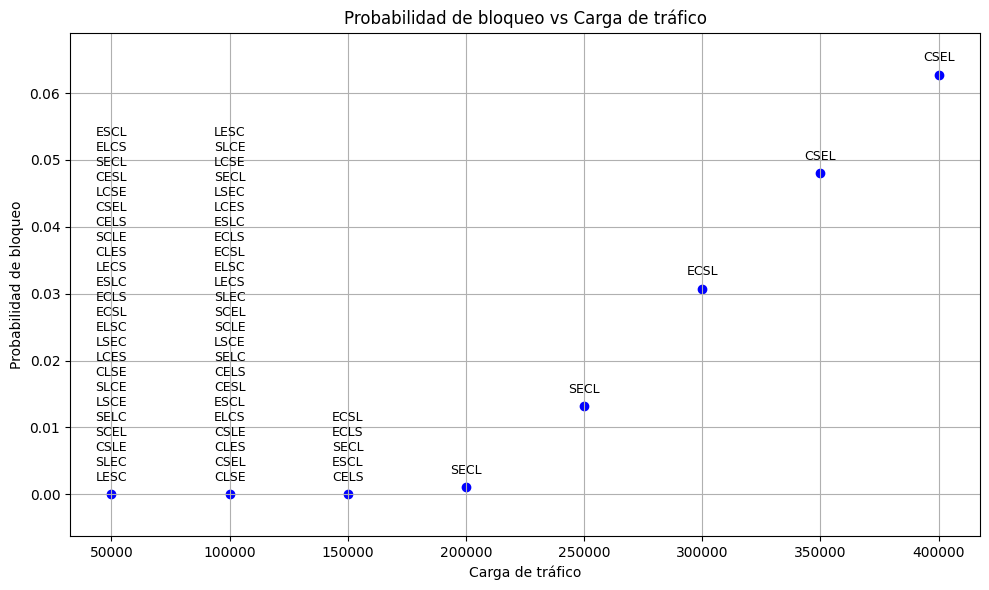

In [21]:
import matplotlib.pyplot as plt

# Convertir eje x a números
eje_x = list(map(int, eje_x))

# Crear scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(eje_x, eje_y, color="blue")
plt.margins(y=0.1)
# Agregar etiquetas sobre cada punto
for i in range(len(eje_x)):
    plt.text(eje_x[i], eje_y[i] + 0.002, labels[i], ha="center", fontsize=9)

# Etiquetas y título
plt.xlabel("Carga de tráfico")
plt.ylabel("Probabilidad de bloqueo")
plt.title("Probabilidad de bloqueo vs Carga de tráfico")
plt.grid(True)
plt.tight_layout()
plt.show()